# 4.2.1 均方误差

In [1]:
import numpy as np

def mean_squared_err(y, t):
    return 0.5 * np.sum((y - t) ** 2)

# 4.2.2 交叉熵误差

In [4]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return np.sum(t * np.log(y + delta))

t = [0, 0, 1]
y = [0.1, 0.05, 0.6]
print(cross_entropy_error(np.array(y), np.array(t)))

-0.510825457099338


# 4.2.3 mini-batch

In [ ]:
import sys, os

sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)
print(x_train.shape)
print(t_train.shape)

train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size)
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]
# print(x_batch)
# print(t_batch)

(60000, 784)
(60000, 10)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


# 4.3 数值微分

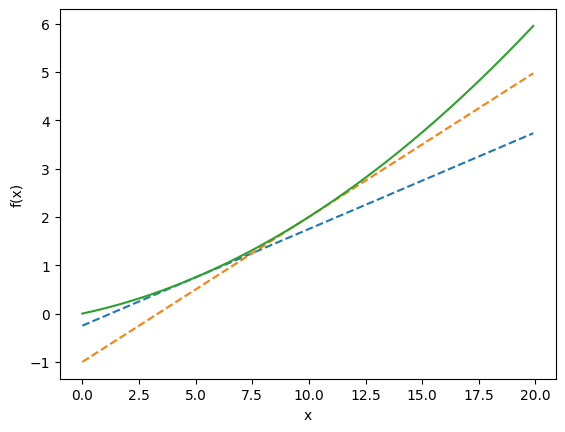

In [14]:
def numerical_diff(f, x):
    h = 1e-4
    return (f(x+h) - f(x-h)) / (2*h)

def function_1(x):
    return 0.01*x**2 + 0.1*x

import numpy as np
from matplotlib import pyplot as plt

# 计算x=5和x=10的导数
def line_5(x):
    diff_5 = numerical_diff(function_1, 5)
    b_5 = function_1(5) - diff_5 * 5
    return diff_5 * x + b_5

def line_10(x):
    diff_10 = numerical_diff(function_1, 10)
    b_10 = function_1(10) - diff_10 * 10
    return diff_10 * x + b_10

plt.xlabel("x")
plt.ylabel("f(x)")

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)

# x=5的切线
plt.plot(x, line_5(x), '--', label="x=5")
# x=10的切线
plt.plot(x, line_10(x), '--', label="x=10")

plt.plot(x, y)
plt.show()